# TT-20 — SVR: Dự đoán cường độ chịu nén bê tông

## 0. Import thư viện & đọc dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
import joblib, time

target = "Concrete compressive strength"

# Đọc thẳng file Excel gốc từ UCI và đổi tên cột cho gọn
df = pd.read_excel("../dataset/Concrete_Data.xls")
df = df.rename(columns={
    "Cement (component 1)(kg in a m^3 mixture)": "Cement",
    "Blast Furnace Slag (component 2)(kg in a m^3 mixture)": "Blast Furnace Slag",
    "Fly Ash (component 3)(kg in a m^3 mixture)": "Fly Ash",
    "Water  (component 4)(kg in a m^3 mixture)": "Water",
    "Superplasticizer (component 5)(kg in a m^3 mixture)": "Superplasticizer",
    "Coarse Aggregate  (component 6)(kg in a m^3 mixture)": "Coarse Aggregate",
    "Fine Aggregate (component 7)(kg in a m^3 mixture)": "Fine Aggregate",
    "Age (day)": "Age",
    "Concrete compressive strength(MPa, megapascals) ": target,
})
features = [c for c in df.columns if c != target]
df.shape

(1030, 9)

## 1. EDA
Scatter từng đặc trưng vs cường độ, và heatmap tương quan.

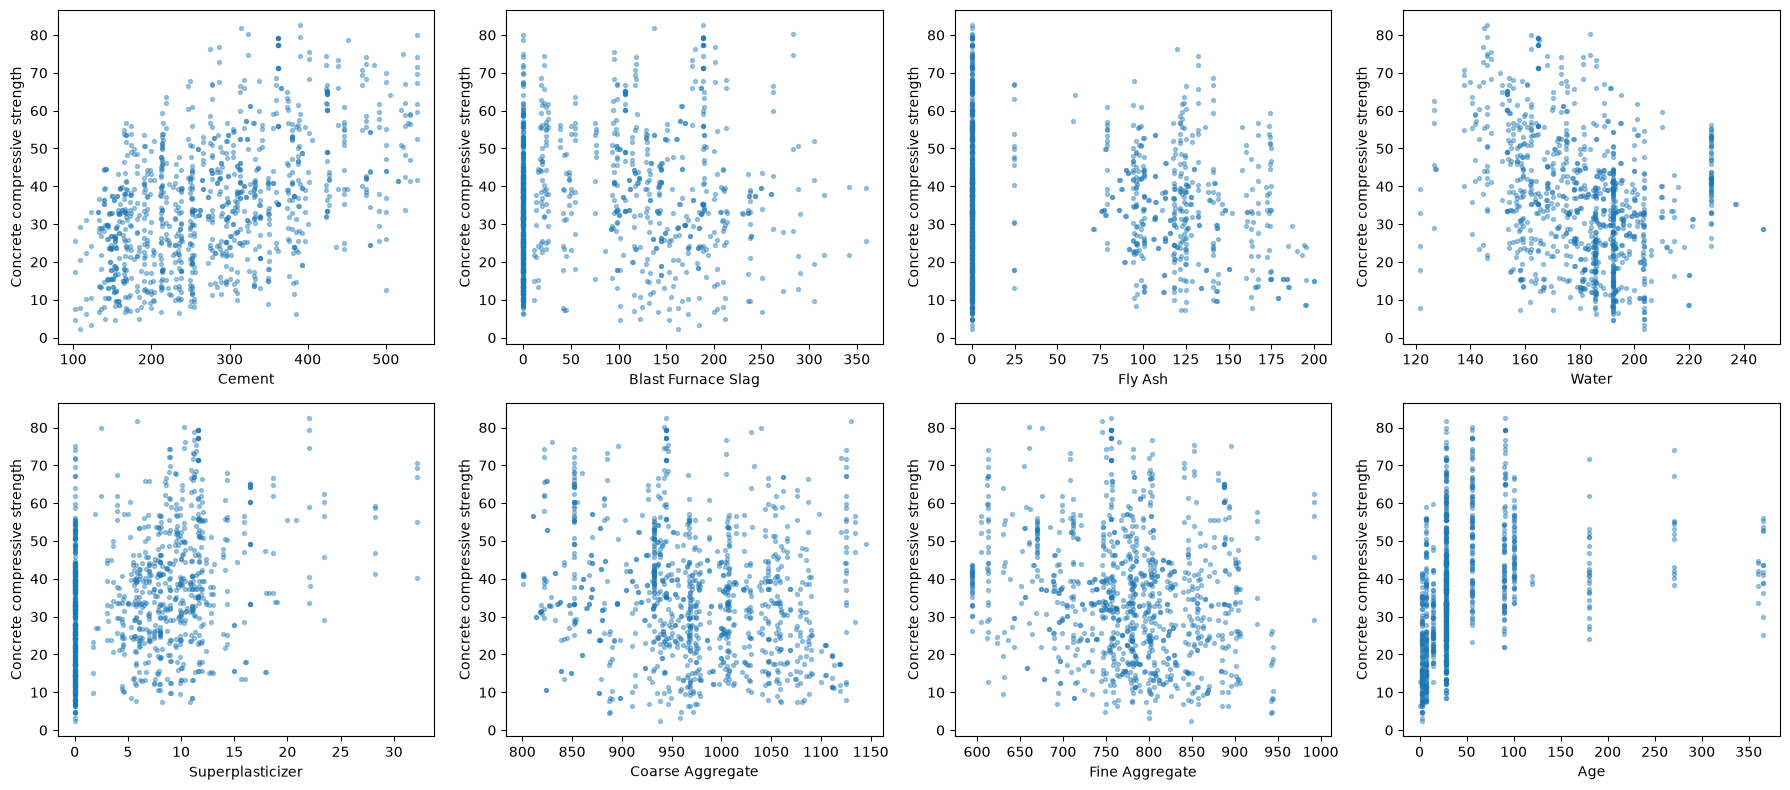

In [2]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, features):
    ax.scatter(df[col], df[target], s=8, alpha=0.4)
    ax.set_xlabel(col); ax.set_ylabel(target)
plt.tight_layout(); plt.show()

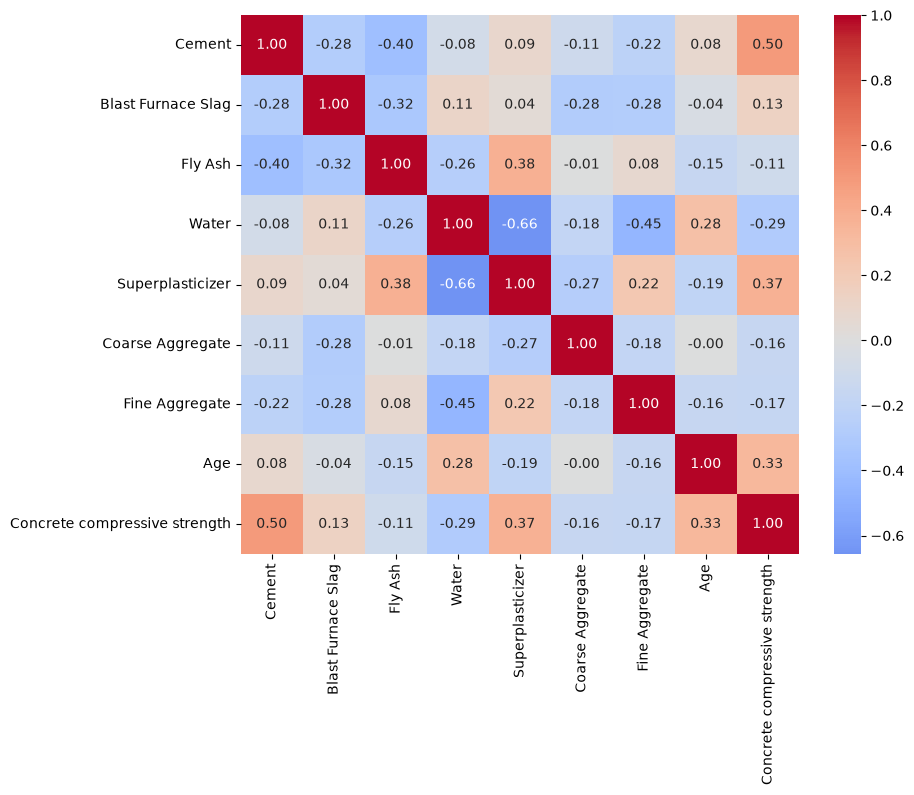

Cement                0.497833
Superplasticizer      0.366102
Age                   0.328877
Water                -0.289613
Fine Aggregate       -0.167249
Coarse Aggregate     -0.164928
Blast Furnace Slag    0.134824
Fly Ash              -0.105753
Name: Concrete compressive strength, dtype: float64

In [3]:
plt.figure(figsize=(9, 7))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.show()
corr[target].drop(target).sort_values(key=lambda s: -s.abs())

**Nhận xét:** không đặc trưng gốc nào có tương quan tuyến tính > 0.5 với target
→ quan hệ phi tuyến, phù hợp để dùng kernel SVR.

## 2. Đặc trưng từ kiến thức miền

| Đặc trưng | Công thức | Lý do |
|---|---|---|
| `water_cement_ratio` | Water / Cement | Tỉ lệ nước/xi măng quyết định độ đặc chắc của bê tông |
| `tong_chat_ket_dinh` | Cement + Slag + Fly Ash | Tro bay, xỉ lò cũng là chất kết dính, không chỉ riêng xi măng |
| `log_age` | log(1 + Age) | Cường độ tăng theo log(tuổi), nhanh 7 ngày đầu rồi chậm dần |

Đây là kiến thức miền — model không tự suy ra được nếu chỉ đưa dữ liệu thô vào.

In [4]:
df["water_cement_ratio"] = df["Water"] / df["Cement"]
df["tong_chat_ket_dinh"] = df["Cement"] + df["Blast Furnace Slag"] + df["Fly Ash"]
df["log_age"] = np.log1p(df["Age"])

print("Tương quan đặc trưng mới với target:")
print(df[["water_cement_ratio", "tong_chat_ket_dinh", "log_age", "Age", target]].corr()[target])

Tương quan đặc trưng mới với target:
water_cement_ratio              -0.500700
tong_chat_ket_dinh               0.613168
log_age                          0.549450
Age                              0.328877
Concrete compressive strength    1.000000
Name: Concrete compressive strength, dtype: float64


`log_age` (0.55) mạnh hơn hẳn `Age` gốc (0.33); `tong_chat_ket_dinh` (0.61) mạnh hơn `Cement` riêng lẻ (0.50).

## 3. Chia train/test & Baseline (Dummy + Linear Regression)

In [5]:
X = df.drop(columns=[target, "Age"])  # dùng log_age thay Age gốc
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for name, model in [("DummyRegressor (mean)", DummyRegressor(strategy="mean")),
                     ("Linear Regression", LinearRegression())]:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    r2 = r2_score(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    print(f"{name:25s}  R2={r2:.4f}   RMSE={rmse:.3f} MPa")

DummyRegressor (mean)      R2=-0.0002   RMSE=16.054 MPa
Linear Regression          R2=0.8305   RMSE=6.609 MPa


## 4-5. SVR: KHÔNG scale vs CÓ scale (cả X và y)

`epsilon` mặc định = 0.1. Với y đo bằng MPa (2–83), 0.1 gần như vô nghĩa
→ hầu hết điểm rơi ra ngoài ống ε-insensitive nếu không scale.

KHONG scale     R2=0.2892  RMSE=13.534
Scale X va y    R2=0.8944  RMSE=5.216
Chi scale X     R2=0.8841  RMSE=5.465


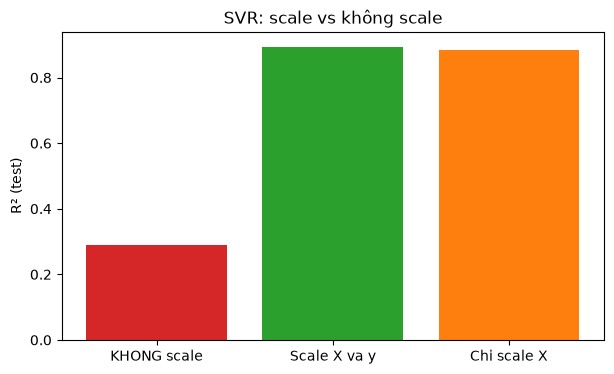

In [6]:
results = {}

# Không scale gì
svr_raw = SVR(kernel="rbf")
svr_raw.fit(X_train, y_train)
pred = svr_raw.predict(X_test)
results["KHONG scale"] = (r2_score(y_test, pred), mean_squared_error(y_test, pred) ** 0.5)

# Scale cả X và y
svr_pipeline = Pipeline([("scale", StandardScaler()),
                          ("svr", SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1))])
model_scaled = TransformedTargetRegressor(regressor=svr_pipeline, transformer=StandardScaler())
model_scaled.fit(X_train, y_train)
pred = model_scaled.predict(X_test)
results["Scale X va y"] = (r2_score(y_test, pred), mean_squared_error(y_test, pred) ** 0.5)

# Chỉ scale X
svr_x_only = Pipeline([("scale", StandardScaler()),
                        ("svr", SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1))])
svr_x_only.fit(X_train, y_train)
pred = svr_x_only.predict(X_test)
results["Chi scale X"] = (r2_score(y_test, pred), mean_squared_error(y_test, pred) ** 0.5)

for name, (r2, rmse) in results.items():
    print(f"{name:15s} R2={r2:.4f}  RMSE={rmse:.3f}")

plt.figure(figsize=(7, 4))
plt.bar(results.keys(), [v[0] for v in results.values()], color=["#d62728", "#2ca02c", "#ff7f0e"])
plt.ylabel("R² (test)"); plt.title("SVR: scale vs không scale"); plt.show()

**Kết luận:** không scale → R² sụp xuống ~0.29. Scale cả X và y cho kết quả tốt nhất.

## 6. So sánh 3 kernel: linear / rbf / poly (degree 2, 3)

In [7]:
configs = {
    "linear": dict(kernel="linear", C=100),
    "rbf": dict(kernel="rbf", C=100, gamma="scale"),
    "poly_d2": dict(kernel="poly", degree=2, C=100, gamma="scale"),
    "poly_d3": dict(kernel="poly", degree=3, C=100, gamma="scale"),
}
rows = []
for name, params in configs.items():
    pipe = Pipeline([("scale", StandardScaler()), ("svr", SVR(epsilon=0.1, **params))])
    m = TransformedTargetRegressor(regressor=pipe, transformer=StandardScaler())
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    r2 = r2_score(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    n_sv = m.regressor_.named_steps["svr"].n_support_.sum()
    rows.append((name, r2, rmse, n_sv))

pd.DataFrame(rows, columns=["kernel", "R2", "RMSE", "n_support_vectors"])

,kernel,R2,RMSE,n_support_vectors
0,linear,0.829425,6.629770,641
1,rbf,0.894398,5.216474,450
2,poly_d2,0.392120,12.515559,717
3,poly_d3,0.815691,6.891507,605


**RBF thắng rõ rệt** — quan hệ phi tuyến phức tạp, `poly` nhạy tham số `coef0` chưa tune.

## 7-8. GridSearchCV: C × gamma × epsilon + heatmap RMSE

In [8]:
svr_pipeline = Pipeline([("scale", StandardScaler()), ("svr", SVR(kernel="rbf"))])
base_model = TransformedTargetRegressor(regressor=svr_pipeline, transformer=StandardScaler())

param_grid = {
    "regressor__svr__C": [1, 10, 100, 1000],
    "regressor__svr__gamma": ["scale", 0.01, 0.1, 1],
    "regressor__svr__epsilon": [0.01, 0.1, 0.5],
}
grid = GridSearchCV(base_model, param_grid, scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("RMSE CV tốt nhất:", -grid.best_score_)

best_model = grid.best_estimator_
pred = best_model.predict(X_test)
print(f"Test: R2={r2_score(y_test, pred):.4f}  RMSE={mean_squared_error(y_test, pred)**0.5:.3f} MPa")

Best params: {'regressor__svr__C': 1000, 'regressor__svr__epsilon': 0.1, 'regressor__svr__gamma': 0.01}
RMSE CV tốt nhất: 4.888255179272846
Test: R2=0.8911  RMSE=5.298 MPa


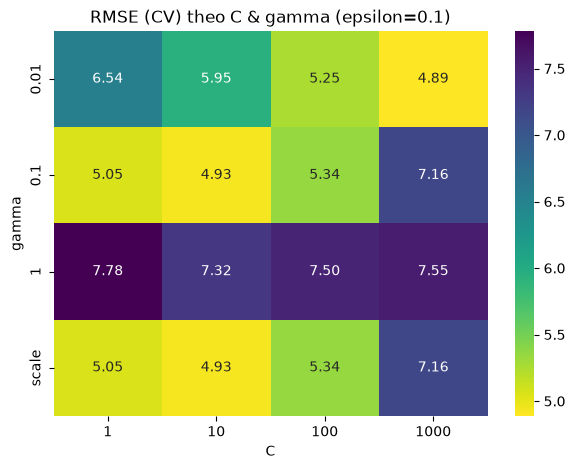

In [9]:
results_df = pd.DataFrame(grid.cv_results_)
best_eps = grid.best_params_["regressor__svr__epsilon"]
sub = results_df[results_df["param_regressor__svr__epsilon"] == best_eps]
pivot = sub.pivot_table(index="param_regressor__svr__gamma", columns="param_regressor__svr__C",
                          values="mean_test_score", aggfunc="mean")
pivot_rmse = -pivot

plt.figure(figsize=(7, 5))
sns.heatmap(pivot_rmse, annot=True, fmt=".2f", cmap="viridis_r")
plt.title(f"RMSE (CV) theo C & gamma (epsilon={best_eps})")
plt.xlabel("C"); plt.ylabel("gamma"); plt.show()

`gamma=1` cho RMSE tệ nhất ở mọi C → overfit rõ rệt. C lớn cần gamma nhỏ tương ứng.

## 9. Đếm support vectors

In [10]:
svr = best_model.regressor_.named_steps["svr"]
n_sv = svr.n_support_.sum()
n_train = len(X_train)
print(f"Support vectors: {n_sv}/{n_train} ({n_sv/n_train*100:.1f}%)")

joblib.dump(best_model, "../models/svr_pipeline.joblib")
print("Đã lưu model.")

Support vectors: 504/824 (61.2%)
Đã lưu model.


## 10. Đo hiệu quả đặc trưng miền: RMSE trước vs sau

In [11]:
raw_features = ["Cement", "Blast Furnace Slag", "Fly Ash", "Water",
                "Superplasticizer", "Coarse Aggregate", "Fine Aggregate", "Age"]
domain_features = raw_features + ["water_cement_ratio", "tong_chat_ket_dinh", "log_age"]

best_params = grid.best_params_
rows = []
for label, cols in [("KHONG dac trung mien", raw_features), ("CO dac trung mien", domain_features)]:
    Xc = df[cols]; yc = df[target]
    Xtr, Xte, ytr, yte = train_test_split(Xc, yc, test_size=0.2, random_state=42)
    pipe = Pipeline([("scale", StandardScaler()),
                      ("svr", SVR(kernel="rbf",
                                  C=best_params["regressor__svr__C"],
                                  gamma=best_params["regressor__svr__gamma"],
                                  epsilon=best_params["regressor__svr__epsilon"]))])
    m = TransformedTargetRegressor(regressor=pipe, transformer=StandardScaler())
    m.fit(Xtr, ytr)
    pred = m.predict(Xte)
    rows.append((label, r2_score(yte, pred), mean_squared_error(yte, pred) ** 0.5))

pd.DataFrame(rows, columns=["config", "R2", "RMSE"])

,config,R2,RMSE
0,KHONG dac trung mien,0.858388,6.040766
1,CO dac trung mien,0.888887,5.350872


Đặc trưng miền giúp RMSE giảm khoảng **11%** — cải thiện đáng kể chỉ nhờ công thức domain-knowledge.

## 11. So sánh SVR vs XGBoost vs Random Forest

In [12]:
svr_pipeline = Pipeline([("scale", StandardScaler()),
                          ("svr", SVR(kernel="rbf",
                                      C=best_params["regressor__svr__C"],
                                      gamma=best_params["regressor__svr__gamma"],
                                      epsilon=best_params["regressor__svr__epsilon"]))])
models = {
    "SVR (RBF, tuned)": TransformedTargetRegressor(regressor=svr_pipeline, transformer=StandardScaler()),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.08, random_state=42),
}

rows = []
for name, m in models.items():
    t0 = time.perf_counter()
    m.fit(X_train, y_train)
    train_time = time.perf_counter() - t0
    pred = m.predict(X_test)
    rows.append((name, r2_score(y_test, pred), mean_squared_error(y_test, pred) ** 0.5, train_time))

pd.DataFrame(rows, columns=["model", "R2", "RMSE", "train_time_s"])

,model,R2,RMSE,train_time_s
0,"SVR (RBF, tuned)",0.891086,5.297657,0.574437
1,Random Forest,0.894060,5.224829,0.285627
2,XGBoost,0.932019,4.185387,0.223513


XGBoost vẫn nhỉnh hơn SVR — khớp mức tham chiếu trong đề bài (XGBoost thường tốt hơn chút).

## 12. Đo thời gian train khi nhân dữ liệu lên nhiều lần
Chứng minh SVR không mở rộng tốt (độ phức tạp ~O(n²)–O(n³)).

n=   824  SVR=  0.589s   XGBoost=  0.108s
n=  1648  SVR=  2.136s   XGBoost=  0.183s
n=  3296  SVR=  8.803s   XGBoost=  0.102s
n=  6592  SVR= 46.531s   XGBoost=  0.134s


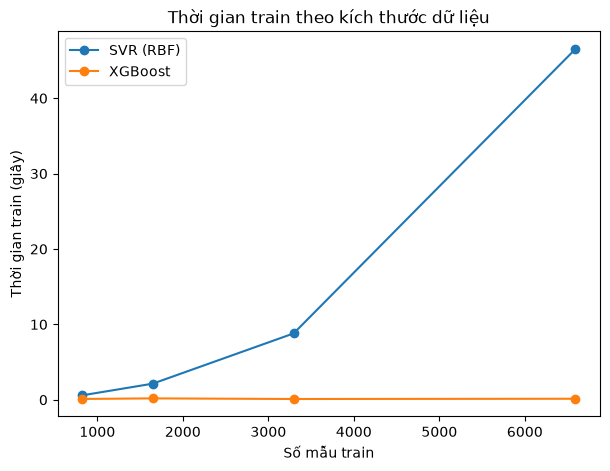

In [13]:
multipliers = [1, 2, 4, 8]
rows = []
for mlt in multipliers:
    X_big = pd.concat([X_train] * mlt, ignore_index=True)
    y_big = pd.concat([y_train] * mlt, ignore_index=True)

    svr_pipeline = Pipeline([("scale", StandardScaler()),
                              ("svr", SVR(kernel="rbf",
                                          C=best_params["regressor__svr__C"],
                                          gamma=best_params["regressor__svr__gamma"],
                                          epsilon=best_params["regressor__svr__epsilon"]))])
    svr_model = TransformedTargetRegressor(regressor=svr_pipeline, transformer=StandardScaler())
    t0 = time.perf_counter(); svr_model.fit(X_big, y_big); svr_time = time.perf_counter() - t0

    xgb_model = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.08, random_state=42)
    t0 = time.perf_counter(); xgb_model.fit(X_big, y_big); xgb_time = time.perf_counter() - t0

    rows.append((len(X_big), svr_time, xgb_time))
    print(f"n={len(X_big):6d}  SVR={svr_time:7.3f}s   XGBoost={xgb_time:7.3f}s")

df_time = pd.DataFrame(rows, columns=["n_samples", "svr_time_s", "xgb_time_s"])
plt.figure(figsize=(7, 5))
plt.plot(df_time["n_samples"], df_time["svr_time_s"], "o-", label="SVR (RBF)")
plt.plot(df_time["n_samples"], df_time["xgb_time_s"], "o-", label="XGBoost")
plt.xlabel("Số mẫu train"); plt.ylabel("Thời gian train (giây)")
plt.title("Thời gian train theo kích thước dữ liệu"); plt.legend(); plt.show()